In [68]:
from flextrees.datasets.tabular_datasets import bank
from flextrees.datasets.tabular_datasets import nursery
from flextrees.datasets.tabular_datasets import adult
from flextrees.datasets.tabular_datasets import ildp,magic,credit2,car
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from utils.evaluation import FL_simple_cross_val_score
from sklearn.datasets import load_breast_cancer
import time
import math
from statds.no_parametrics import friedman, bonferroni, nemenyi
import os
import matplotlib.pyplot as plt

In [69]:
datasets = ['bank',
            'adult','nursery','credit','car',
            'covertype','magic','pendig']

In [70]:
datasets2 = ['nursery','car',
            'covertype','pendig']

In [71]:
path = os.path.abspath('')

In [72]:
Nclients = 20

In [73]:
def processDataFrame(dataframe,dataframe1,datasets):
    global_dataframeFed = dataframe[[x for x in dataframe.columns if 'global' in x]]
    global_dataframeNFed =  dataframe1[[x for x in dataframe1.columns if 'global' in x]]
    local_dataframeFed = dataframe[[x for x in dataframe.columns if 'local' in x]]
    local_dataframeNFed =  dataframe1[[x for x in dataframe1.columns if 'local' in x]]
    stats_dataframe = pd.concat([dataframe.iloc[:,0],global_dataframeFed,global_dataframeNFed],axis=1)
    auxglobaldataframe = pd.concat([global_dataframeFed,global_dataframeNFed],axis=1)
    auxlocaldataframe = pd.concat([local_dataframeFed,local_dataframeNFed],axis=1)
    filter = np.array(range(auxglobaldataframe.shape[0])).reshape(-1,6)
    num_datasets = filter.shape[0]
    global_mean = pd.DataFrame(np.nan, index = datasets,
                            columns = auxglobaldataframe.columns)
    local_mean = pd.DataFrame(np.nan, index = datasets,
                            columns = auxlocaldataframe.columns)
    for i in range(num_datasets):
        global_mean.iloc[i] = auxglobaldataframe.iloc[filter[i]].mean(axis=0)
        local_mean.iloc[i] = auxlocaldataframe.iloc[filter[i]].mean(axis=0)
    return stats_dataframe,global_mean,local_mean

In [74]:
distribs= ['iid','niid_quantity_skew','niid_dirichlet_label_skew']
#distribs= ['iid','niid_quantity_skew']

#Nclients=10
statResults = [None]*len(distribs)
for i,distrib in enumerate(distribs):
    dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_acc_'+ str(Nclients))
    dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Notfed_acc_'+ str(Nclients))
    statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets)
    global_mean = global_mean.round(decimals=3)
    local_mean = local_mean.round(decimals=3)
    global_mean.to_csv(path + '\\fase2\\avgresult'+str(Nclients)+ '\\global_acc_'+distrib+str(Nclients)+'.csv')
    local_mean.to_csv(path + '\\fase2\\avgresult'+str(Nclients)+ '\\local_acc_'+distrib+str(Nclients)+'.csv')
    statResults[i] = statsDataframe



In [75]:
distrib = 'niid_label_quantity_skew'
dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_acc_'+ str(Nclients))
dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Notfed_acc_'+ str(Nclients))
statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets2)
global_mean = global_mean.round(decimals=3)
local_mean = local_mean.round(decimals=3)
global_mean.to_csv(path + '\\fase2\\avgresult'+str(Nclients)+ '\\global_acc_'+distrib+str(Nclients)+'.csv')
local_mean.to_csv(path + '\\fase2\\avgresult'+str(Nclients)+ '\\local_acc_'+distrib+str(Nclients)+'.csv')
statResults.append(statsDataframe)

# Accuracy IID

In [76]:
statdata = statResults[0]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)



Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 132.14999999999998, p-value 7.123313050527713e-11
{'o_s_Wmv_cw_global': 2.875, 'o_s_Wmv_aw_global': 2.9375, 's_c_b_nb_Wmv_aw_global': 2.875, 'centralized_global': 1.3125, 'loc_model_global': 5.0}


[2.875, 2.9375, 2.875, 1.3125, 5.0]
0.8803855042622207


C:\Users\mario\AppData\Local\Temp\ipykernel_12448\3334119522.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


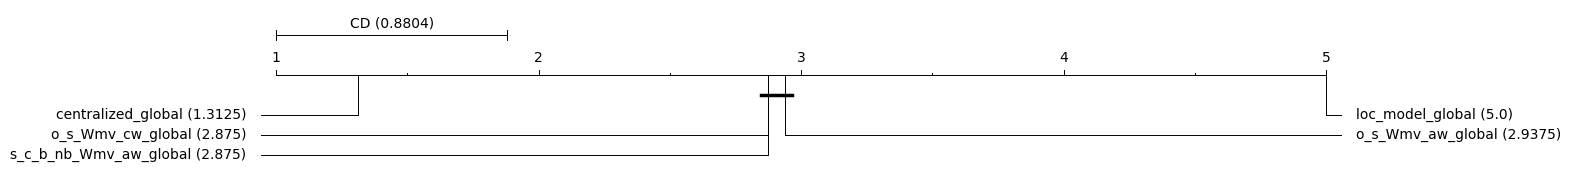

In [77]:

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


In [78]:
pd.DataFrame(ranks_values).transpose().round(decimals=3)

,0,1,2,3,4
0,2.875,2.938,2.875,1.312,5.0


# Accuracy NIID-QS

In [79]:
statdata = statResults[1]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


Overall comparison:



Reject H0 with alpha = 0.05 (Different distributions)
Statistic 137.51249999999993, p-value 1.1373635366851431e-10
{'o_s_Wmv_cw_global': 2.7916666666666665, 'o_s_Wmv_aw_global': 3.1875, 's_c_b_nb_Wmv_aw_global': 2.7604166666666665, 'centralized_global': 1.2604166666666667, 'loc_model_global': 5.0}


[2.7916666666666665, 3.1875, 2.7604166666666665, 1.2604166666666667, 5.0]
0.8803855042622207


C:\Users\mario\AppData\Local\Temp\ipykernel_12448\3334119522.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


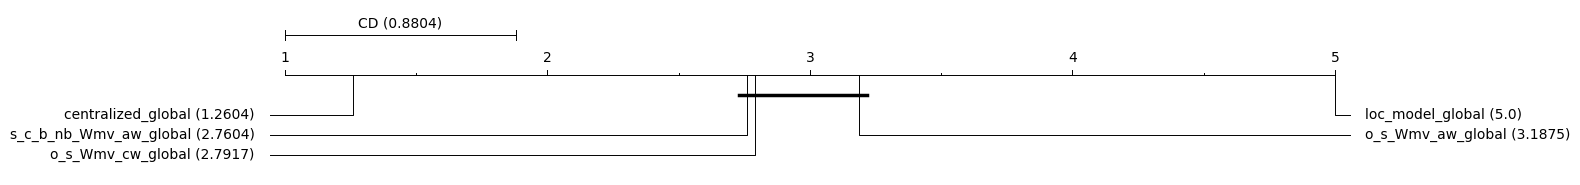

In [80]:

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


In [81]:
pd.DataFrame(ranks_values).transpose().round(decimals=3)

,0,1,2,3,4
0,2.792,3.188,2.76,1.26,5.0


# Accuracy noIID DLS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 157.2791666666667, p-value 8.712697230350841e-11
{'o_s_Wmv_cw_global': 2.8645833333333335, 'o_s_Wmv_aw_global': 3.3541666666666665, 's_c_b_nb_Wmv_aw_global': 2.78125, 'centralized_global': 1.0, 'loc_model_global': 5.0}
[2.8645833333333335, 3.3541666666666665, 2.78125, 1.0, 5.0]
0.8803855042622207


C:\Users\mario\AppData\Local\Temp\ipykernel_12448\3109710221.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


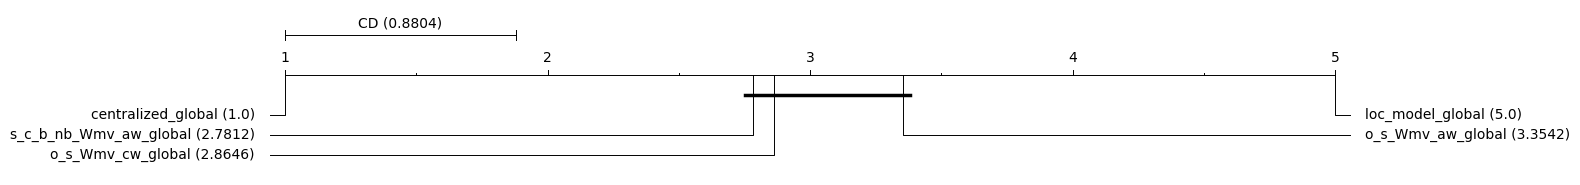

In [82]:
statdata = statResults[2]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


In [83]:
pd.DataFrame(ranks_values).transpose().round(decimals=3)

,0,1,2,3,4
0,2.865,3.354,2.781,1.0,5.0


# Accuracy noIID DLQS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 76.80000000000001, p-value 6.240907790555639e-11
{'o_s_Wmv_cw_global': 3.0, 'o_s_Wmv_aw_global': 3.0, 's_c_b_nb_Wmv_aw_global': 3.0, 'centralized_global': 1.0, 'loc_model_global': 5.0}
[3.0, 3.0, 3.0, 1.0, 5.0]
1.245053120244309


C:\Users\mario\AppData\Local\Temp\ipykernel_12448\1176126289.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


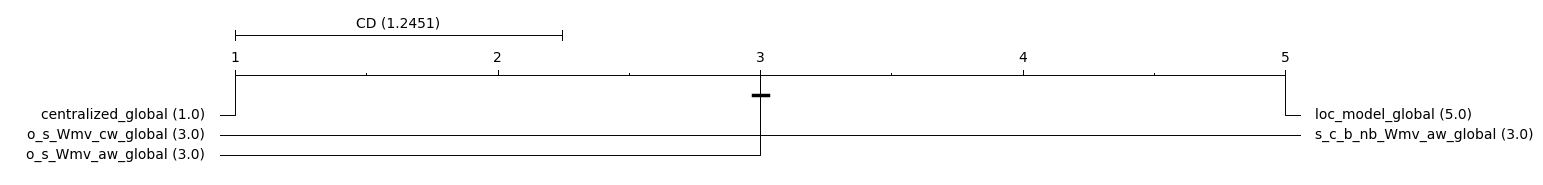

In [84]:
statdata = statResults[3]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)

num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


In [85]:
pd.DataFrame(ranks_values).transpose().round(decimals=3)

,0,1,2,3,4
0,3.0,3.0,3.0,1.0,5.0


# F1 Results

In [86]:
distribs= ['iid','niid_quantity_skew','niid_dirichlet_label_skew']
#distribs= ['iid','niid_quantity_skew']

#Nclients=10
statResults = [None]*len(distribs)
for i,distrib in enumerate(distribs):
    dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_f1_'+ str(Nclients))
    dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_notfed_f1_'+ str(Nclients))
    statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets)
    global_mean = global_mean.round(decimals=3)
    local_mean = local_mean.round(decimals=3)
    global_mean.to_csv(path + '\\fase2\\avgresult'+str(Nclients)+ '\\global_f1_'+distrib+str(Nclients)+'.csv')
    local_mean.to_csv(path + '\\fase2\\avgresult'+str(Nclients)+ '\\local_f1_'+distrib+str(Nclients)+'.csv')
    statResults[i] = statsDataframe

In [87]:
distrib = 'niid_label_quantity_skew'
dataframe = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_Mymodels_f1_'+ str(Nclients))
dataframe1 = pd.read_csv(path + '\\results'+str(Nclients) + 'clients\\'+ distrib + '_notfed_f1_'+ str(Nclients))
statsDataframe,global_mean,local_mean = processDataFrame(dataframe,dataframe1,datasets2)
global_mean = global_mean.round(decimals=3)
local_mean = local_mean.round(decimals=3)
global_mean.to_csv(path + '\\fase2\\avgresult'+str(Nclients)+ '\\global_f1_'+distrib+str(Nclients)+'.csv')
local_mean.to_csv(path + '\\fase2\\avgresult'+str(Nclients)+ '\\local_f1_'+distrib+str(Nclients)+'.csv')
statResults.append(statsDataframe)

# F1-score IID

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 112.94999999999993, p-value 9.6379459968432e-11
{'o_s_Wmv_cw_global': 2.75, 'o_s_Wmv_aw_global': 2.8125, 's_c_b_nb_Wmv_aw_global': 2.75, 'centralized_global': 1.6875, 'loc_model_global': 5.0}
[2.75, 2.8125, 2.75, 1.6875, 5.0]
0.8803855042622207


C:\Users\mario\AppData\Local\Temp\ipykernel_12448\1993031218.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


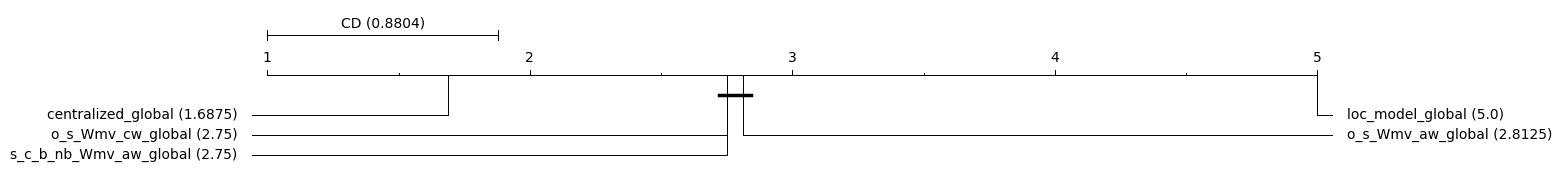

In [88]:
statdata = statResults[0]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


In [89]:
pd.DataFrame(ranks_values).transpose().round(decimals=3)

,0,1,2,3,4
0,2.75,2.812,2.75,1.688,5.0


# F1-score no-IID QS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 123.11666666666667, p-value 5.664491098400504e-11
{'o_s_Wmv_cw_global': 2.8125, 'o_s_Wmv_aw_global': 3.0416666666666665, 's_c_b_nb_Wmv_aw_global': 2.6458333333333335, 'centralized_global': 1.5, 'loc_model_global': 5.0}
[2.8125, 3.0416666666666665, 2.6458333333333335, 1.5, 5.0]
0.8803855042622207


C:\Users\mario\AppData\Local\Temp\ipykernel_12448\21045223.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


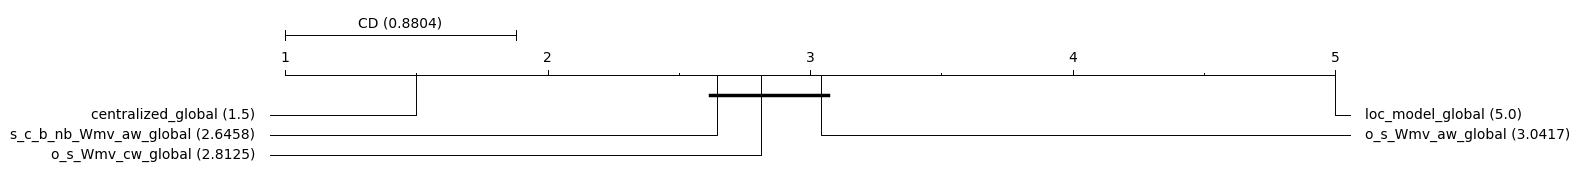

In [90]:
statdata = statResults[1]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


In [91]:
pd.DataFrame(ranks_values).transpose().round(decimals=3)

,0,1,2,3,4
0,2.812,3.042,2.646,1.5,5.0


# F1-score no-IID DLS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 120.0041666666666, p-value 9.695877434268141e-11
{'o_s_Wmv_cw_global': 2.8125, 'o_s_Wmv_aw_global': 3.0104166666666665, 's_c_b_nb_Wmv_aw_global': 2.6145833333333335, 'centralized_global': 1.5625, 'loc_model_global': 5.0}
[2.8125, 3.0104166666666665, 2.6145833333333335, 1.5625, 5.0]
0.8803855042622207


C:\Users\mario\AppData\Local\Temp\ipykernel_12448\3559529400.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


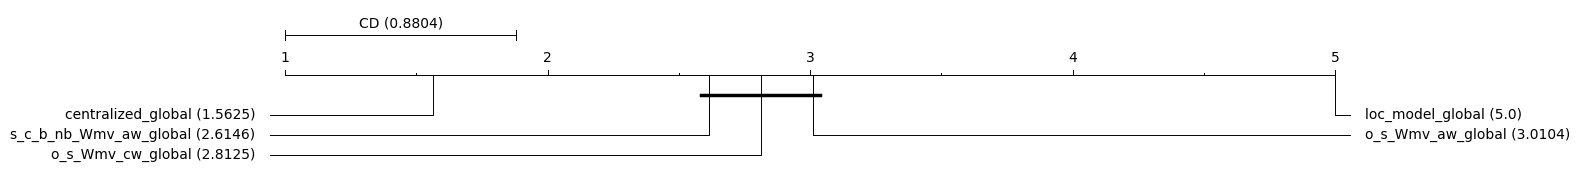

In [92]:
statdata = statResults[2]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


In [93]:
pd.DataFrame(ranks_values).transpose().round(decimals=3)

,0,1,2,3,4
0,2.812,3.01,2.615,1.562,5.0


# F1-score no-IID DLQS

Overall comparison:

Reject H0 with alpha = 0.05 (Different distributions)
Statistic 76.80000000000001, p-value 6.240907790555639e-11
{'o_s_Wmv_cw_global': 3.0, 'o_s_Wmv_aw_global': 3.0, 's_c_b_nb_Wmv_aw_global': 3.0, 'centralized_global': 1.0, 'loc_model_global': 5.0}


[3.0, 3.0, 3.0, 1.0, 5.0]
1.245053120244309


C:\Users\mario\AppData\Local\Temp\ipykernel_12448\802260200.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


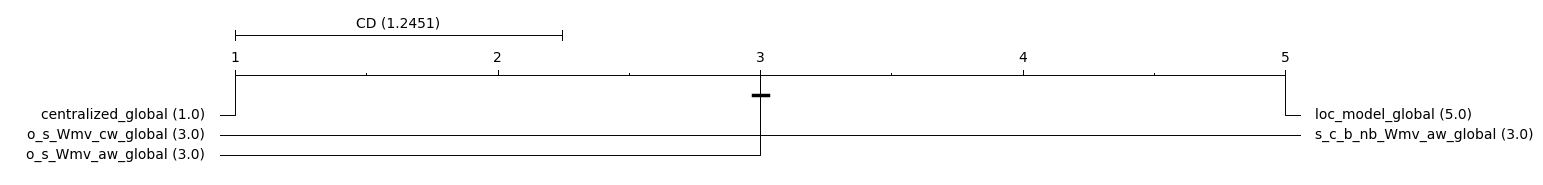

In [94]:
statdata = statResults[3]
alpha = 0.05
rankings, statistic, p_value, critical_value, hypothesis = friedman(statdata, alpha, minimize=False)
print("Overall comparison:\n")
print(hypothesis)
print(f"Statistic {statistic}, p-value {p_value}")
print(rankings)


num_cases = statdata.shape[0]
ranks_values, critical_distance_nemenyi, figure = nemenyi(rankings, num_cases, alpha)
print(ranks_values)
print(critical_distance_nemenyi)
figure.show()


In [95]:
pd.DataFrame(ranks_values).transpose().round(decimals=3)

,0,1,2,3,4
0,3.0,3.0,3.0,1.0,5.0


# Comparison plots

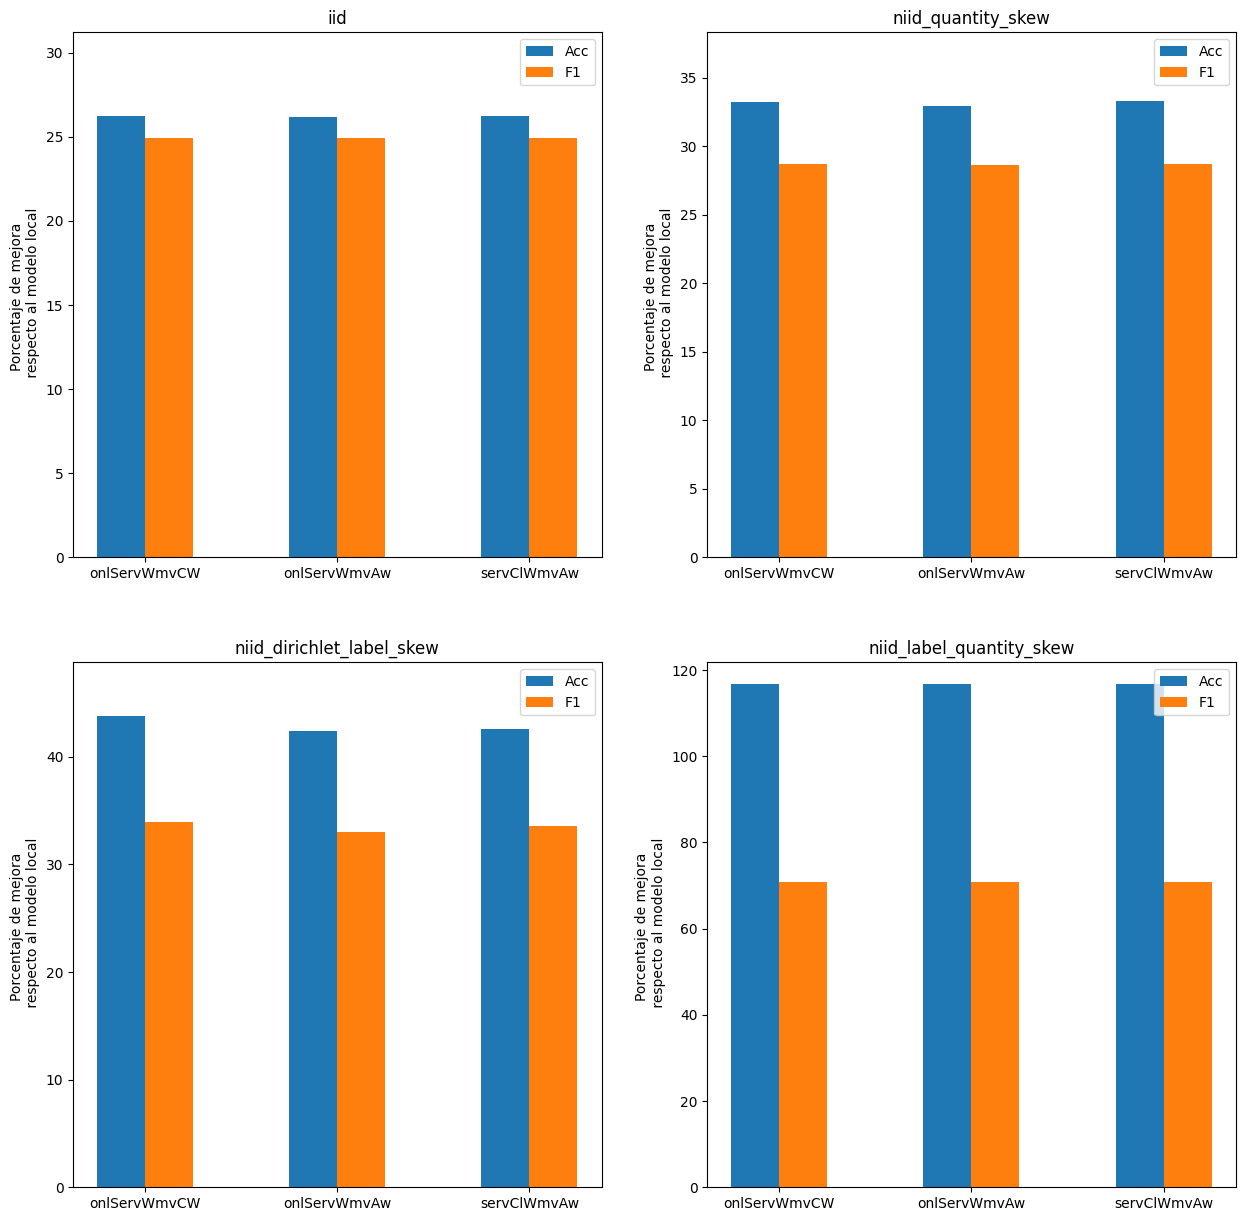

In [98]:
labels = ['onlServWmvCW','onlServWmvAw','servClWmvAw']
distribs = ['iid','niid_quantity_skew','niid_dirichlet_label_skew','niid_label_quantity_skew']
#distribs = ['iid','niid_quantity_skew']
fig,axs = plt.subplots(2,2,figsize=(15,15))
axs = axs.flatten()
x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars


for i,distrib in enumerate(distribs):
    global_dataframeAcc = pd.read_csv(path+'\\fase2\\avgresult' + str(Nclients)+'\\global_acc_'+distrib+str(Nclients)+'.csv')
    global_dataframef1 = pd.read_csv(path+'\\fase2\\avgresult' + str(Nclients)+'\\global_f1_'+distrib+str(Nclients)+'.csv')
    o_sCWAcc = (((global_dataframeAcc['o_s_Wmv_cw_global'] - global_dataframeAcc['loc_model_global'])/global_dataframeAcc['loc_model_global'])*100).mean()
    o_sCWF1 = (((global_dataframef1['o_s_Wmv_cw_global'] - global_dataframef1['loc_model_global'])/global_dataframef1['loc_model_global'])*100).mean()
    o_sAWAcc = (((global_dataframeAcc['o_s_Wmv_aw_global'] - global_dataframeAcc['loc_model_global'])/global_dataframeAcc['loc_model_global'])*100).mean()
    o_sAWF1 = (((global_dataframef1['o_s_Wmv_aw_global'] - global_dataframef1['loc_model_global'])/global_dataframef1['loc_model_global'])*100).mean()
    s_clAWAcc = (((global_dataframeAcc['s_c_b_nb_Wmv_aw_global'] - global_dataframeAcc['loc_model_global'])/global_dataframeAcc['loc_model_global'])*100).mean()
    s_clAWF1 = (((global_dataframef1['s_c_b_nb_Wmv_aw_global'] - global_dataframef1['loc_model_global'])/global_dataframef1['loc_model_global'])*100).mean()


    acc_improve = [o_sCWAcc,o_sAWAcc,s_clAWAcc]
    f1_improve = [o_sCWF1,o_sAWF1,s_clAWF1]

    rects1 = axs[i].bar(x - width/2, acc_improve, width, label='Acc')
    rects2 = axs[i].bar(x + width/2, f1_improve, width, label='F1')

    # Add some text for labels, title and custom x-axis tick labels, etc.
    axs[i].set_ylabel('Porcentaje de mejora \n respecto al modelo local')
    axs[i].set_title(distrib)
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(labels)
    axs[i].legend(loc='upper right')
    lim = max(acc_improve + f1_improve) + 5
    axs[i].set_ylim(0, lim)
